In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
from matplotlib.colors import LogNorm

In [2]:
files = glob('../data/sweep/*.csv')
file = files[3]
print(file)
data = pd.read_csv(
    file, header=3
    )

fs = file.split('_')

p = float(fs[2][1:])
e = float(fs[1][1:])
a = float(fs[3][1:])
m = int(fs[4][1:])
n = int(fs[5].split('.')[0][1:])

r_min = p / (1 + e)   # periastron
r_max = p / (1 - e)   # apastron

../data/sweep/scan_e0.1_p8_a0.5_m2_n2.csv


In [3]:
print(np.unique(data["N"]))
print(np.unique(data["method"]))

[    0   128   256   512  1024  2048  4096  8192 16384]
['fft' 'minospline' 'qag_ref' 'simpson' 'spline' 'trap']


In [4]:
r, th, err = data[
    (data["N"] == 256)&(data["method"]=="trap")
    ][
        ["rField", "theta", "err_max"]
    ].to_numpy().T

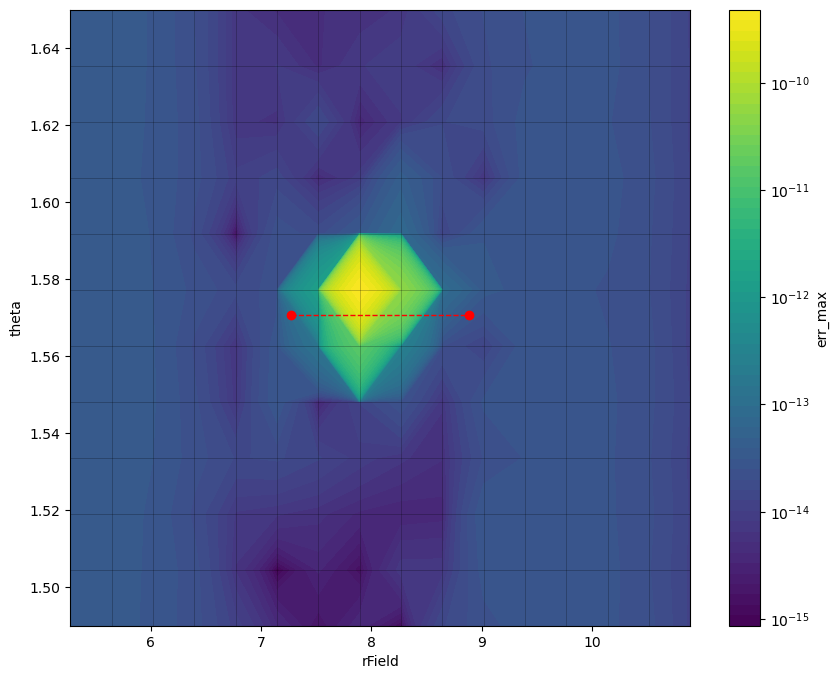

In [5]:
# regular grid -> reshape
from matplotlib.ticker import LogLocator, LogFormatterSciNotation

ru, thu = np.unique(r), np.unique(th)
R, TH = np.meshgrid(ru, thu, indexing='ij')
E = err.reshape(len(ru), len(thu))

fig, ax = plt.subplots(figsize=(10,8))
cf = ax.contourf(R, TH, E, levels=np.logspace(np.log10(err.min()), np.log10(err.max()), 60),
                 norm=LogNorm(), cmap='viridis')
fig.colorbar(cf, label='err_max',
             ticks=LogLocator(numticks=12),
             format=LogFormatterSciNotation())
# faint grid at sample locations
ax.vlines(ru, thu.min(), thu.max(), color='k', lw=0.4, alpha=0.4)
ax.hlines(thu, ru.min(), ru.max(), color='k', lw=0.4, alpha=0.4)
ax.hlines(np.pi/2, r_min, r_max, color='r', ls='--', lw=1)
ax.scatter([r_min,r_max],[np.pi/2, np.pi/2], c='r')
ax.set_xlabel('rField'); ax.set_ylabel('theta')
plt.show()

## n-mode integrator comparison (recontest round-trip)

Error floor vs truncation `nMax` for every enabled integrator, at one field point.
Past the spectral-truncation knee the curves flatten at each method's quadrature
floor, so this separates `qag` / `qagmino` / `minospline` / `minotrap` /
`minosimpson` / `fft` / `trapezoid`. Reads `data/recon.csv` — produce it with
`./bin/recontest test/recon.cfg` (use a field point **outside** the radial range
`[p/(1+e), p/(1-e)]` so the spectrum decays and the floors are meaningful).

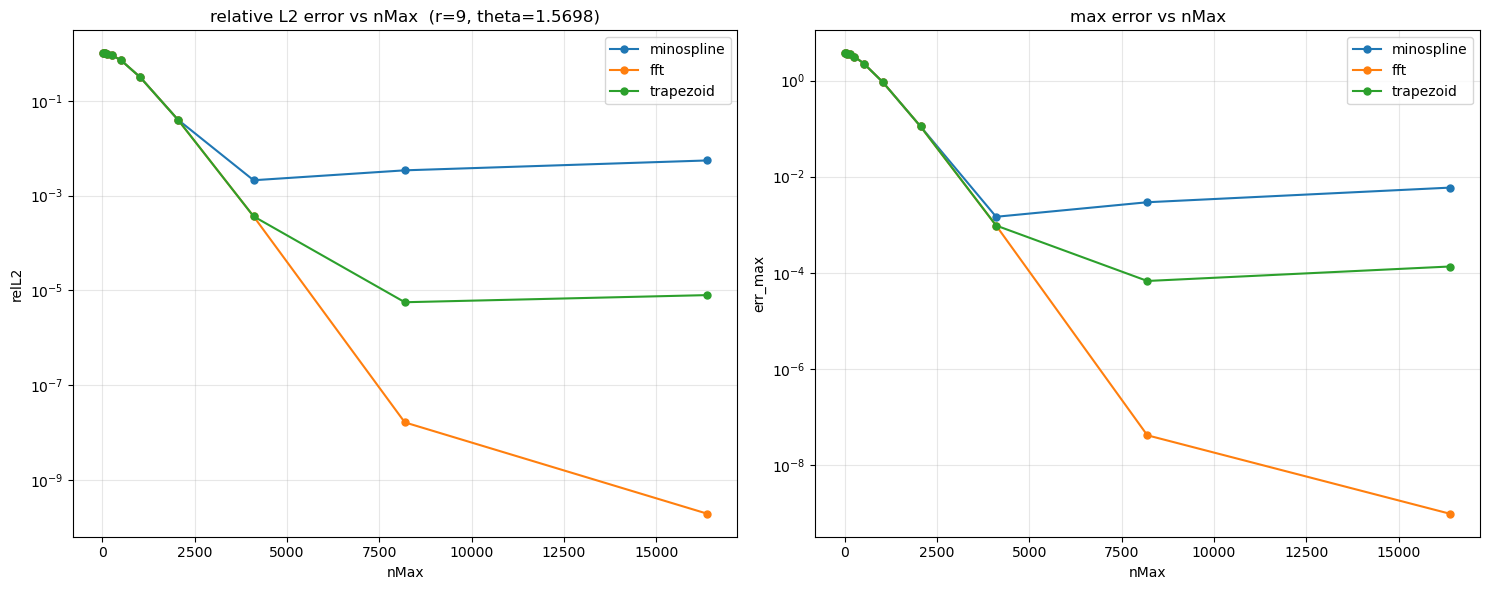

error floor at nMax=16384 (r=9, theta=1.5698):
                   relL2       err_max
method                                
fft         1.939439e-10  9.720556e-10
trapezoid   7.936314e-06  1.351262e-04
minospline  5.500787e-03  5.912963e-03


In [13]:
# n-mode integrator comparison: reconstruction error floor vs truncation nMax.
# Reads the recontest round-trip output (one row per method/nMax/field point).
recon = pd.read_csv('../data/recon.csv', comment='#')

# pick the first field point
rF, th = recon.rField.iloc[0], recon.theta.iloc[0]
sub = recon[(recon.rField == rF) & (recon.theta == th)].copy()
sub['relL2'] = sub.err_l2 / sub.Sdirect_l2   # relative L2 (Sdirect_l2 normalizes)

# stable method order + markers
order = [ 'minospline', 'minotrap', 'minosimpson', 'fft', 'trapezoid']
methods = [m for m in order if m in sub.method.unique()]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for col, ax in zip(['relL2', 'err_max'], axes):
    for m in methods:
        d = sub[sub.method == m].sort_values('nMax')
        ax.semilogy(d.nMax, d[col], 'o-', ms=5, label=m)
    ax.set_xlabel('nMax'); ax.set_ylabel(col); ax.grid(True, which='both', alpha=0.3)
    ax.legend()
axes[0].set_title(f'relative L2 error vs nMax  (r={rF:g}, theta={th:g})')
axes[1].set_title('max error vs nMax')
plt.tight_layout(); plt.show()

# floor table: smallest error reached (largest nMax) per method
nmax = sub.nMax.max()
floor = sub[sub.nMax == nmax].set_index('method')[['relL2', 'err_max']].reindex(methods)
print(f'error floor at nMax={nmax} (r={rF:g}, theta={th:g}):')
print(floor.sort_values('relL2'))